In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()

In [4]:
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df['target'] = iris.target

In [5]:
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
93,5.0,2.3,3.3,1.0,1
45,4.8,3.0,1.4,0.3,0
55,5.7,2.8,4.5,1.3,1
24,4.8,3.4,1.9,0.2,0
72,6.3,2.5,4.9,1.5,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
df.shape

(150, 5)

In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


<Figure size 600x300 with 0 Axes>

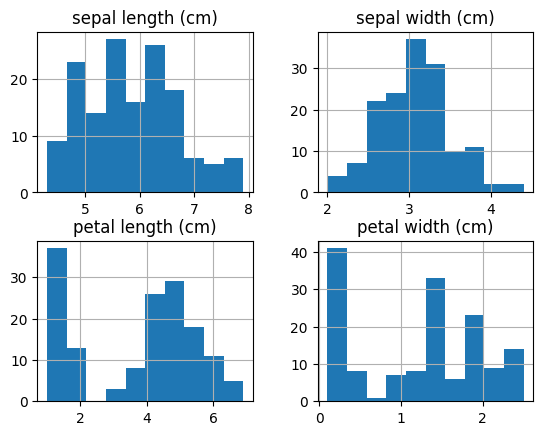

In [9]:
plt.figure(figsize=(6,3))
df.drop('target',axis=1).hist()
plt.show()

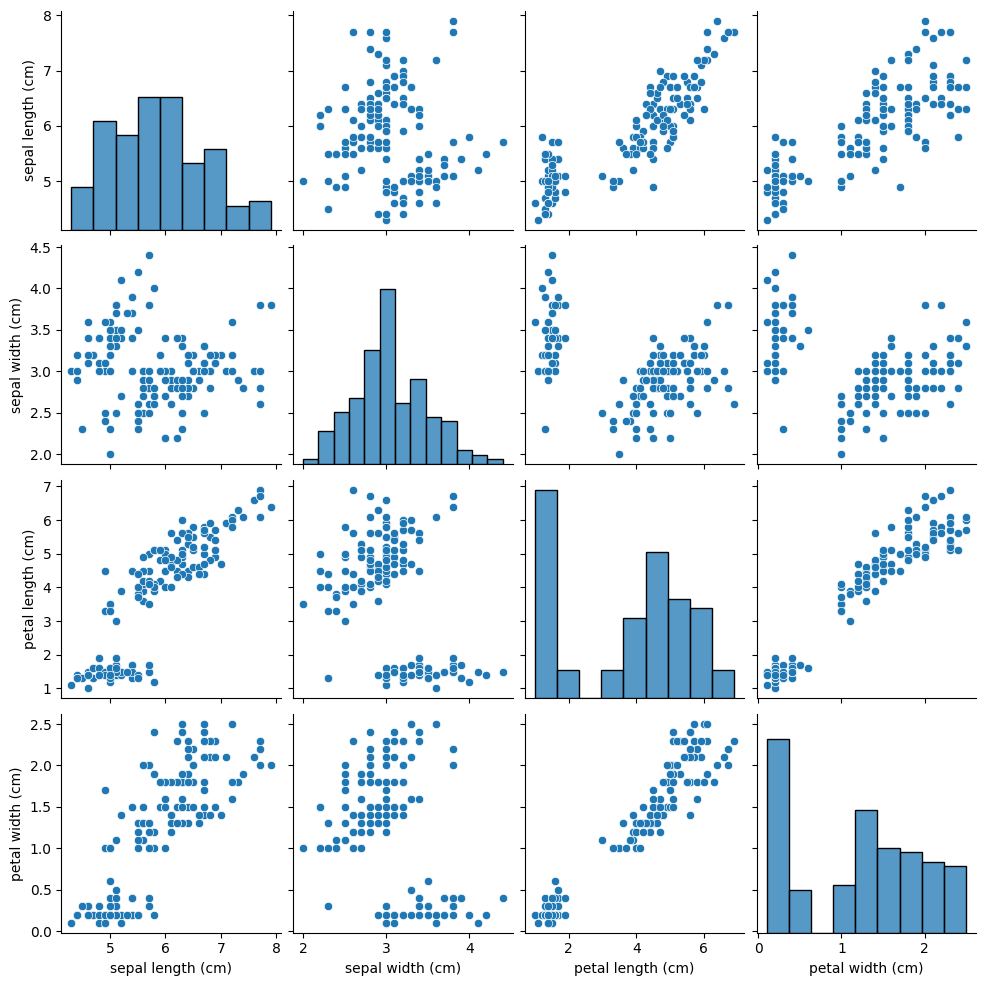

In [10]:
sns.pairplot(data=df.drop(columns='target',axis=1))
plt.show()

In [11]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


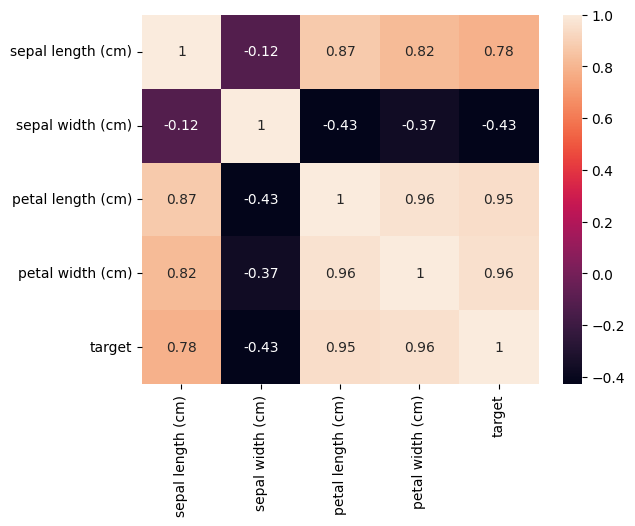

In [12]:
sns.heatmap(data=df.corr(),annot=True)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X = df.drop('target',axis=1)
y = df['target']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
dc = DecisionTreeClassifier()

In [19]:
dc.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
y_pred = dc.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
accuracy_score(y_test,y_pred)

1.0

In [23]:
y_pred_train = dc.predict(X_train)

In [24]:
accuracy_score(y_train,y_pred_train)

1.0

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [26]:
confusion_matrix(y_test,y_pred)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

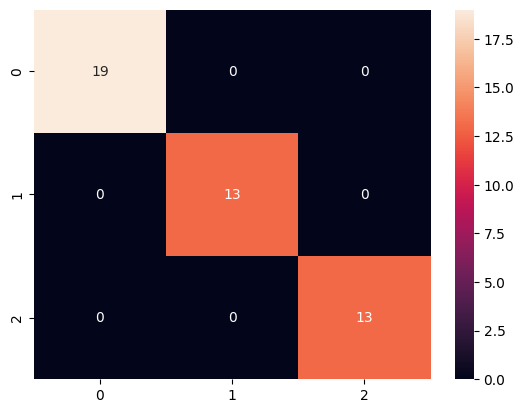

In [27]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)
plt.show()

In [29]:
model1 = DecisionTreeClassifier(criterion="gini", random_state=42)
model1.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
model2 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model2.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
model3 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)
model3.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
model4 = DecisionTreeClassifier(
    criterion="gini",
    min_samples_split=10,
    random_state=42
)
model4.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)
pred4 = model4.predict(X_test)

In [34]:
print("Gini Accuracy:", accuracy_score(y_test, pred1))
print("Entropy Accuracy:", accuracy_score(y_test, pred2))
print("Max Depth=3 Accuracy:", accuracy_score(y_test, pred3))
print("Min Samples Split=10 Accuracy:", accuracy_score(y_test, pred4))

Gini Accuracy: 1.0
Entropy Accuracy: 0.9777777777777777
Max Depth=3 Accuracy: 1.0
Min Samples Split=10 Accuracy: 1.0
